In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Display dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


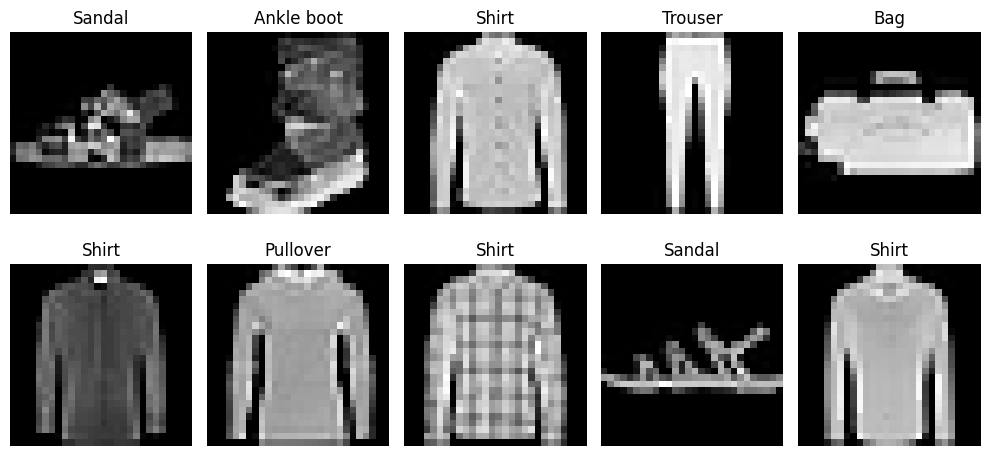

In [4]:
# Class names
class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

# Display 10 random images
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


In [7]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [8]:
import numpy as np

# Convert back to original labels for counting
labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(labels, return_counts=True)

print("Class Distribution:")
for u,c in zip(unique, counts):
    print(class_names[u], ":", c)

Class Distribution:
T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


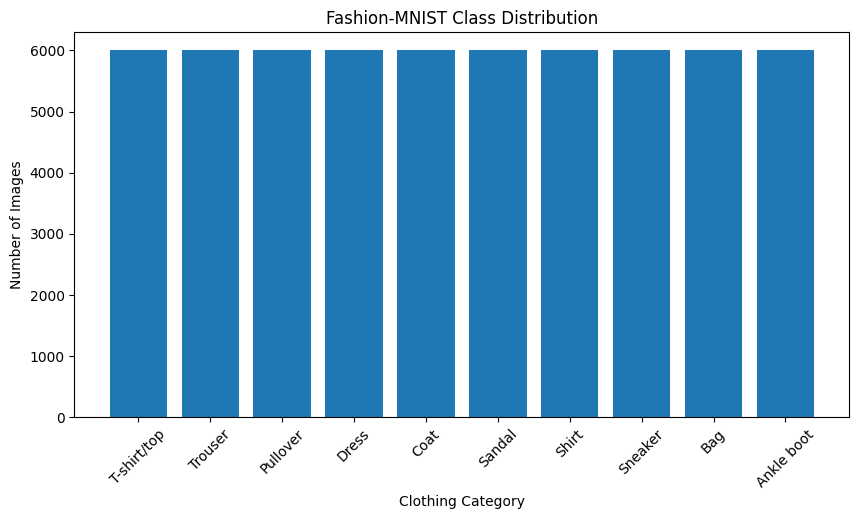

In [9]:
plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.xticks(rotation=45)
plt.title("Fashion-MNIST Class Distribution")
plt.xlabel("Clothing Category")
plt.ylabel("Number of Images")

plt.show()

In [10]:
# Import required libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


# Build CNN model
model = Sequential([

    # Input + First Convolution Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    # Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),

    # Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Flatten layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')

])


# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7551 - loss: 0.7034 - val_accuracy: 0.8423 - val_loss: 0.4266
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8693 - loss: 0.3520 - val_accuracy: 0.8882 - val_loss: 0.3043
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8948 - loss: 0.2851 - val_accuracy: 0.8981 - val_loss: 0.2866
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9085 - loss: 0.2513 - val_accuracy: 0.8997 - val_loss: 0.2695
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9176 - loss: 0.2249 - val_accuracy: 0.9010 - val_loss: 0.2759
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9241 - loss: 0.2043 - val_accuracy: 0.9123 - val_loss: 0.2443
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9327 - loss: 0.1834 - val_accuracy: 0.9137 - val_loss: 0.2422
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9415 - loss: 0.1604 - val_accuracy: 0.

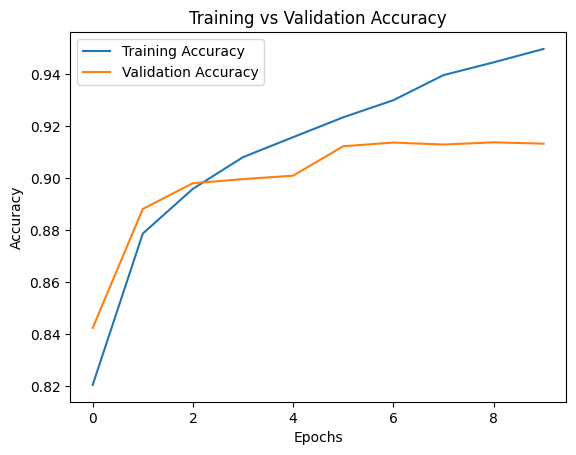

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

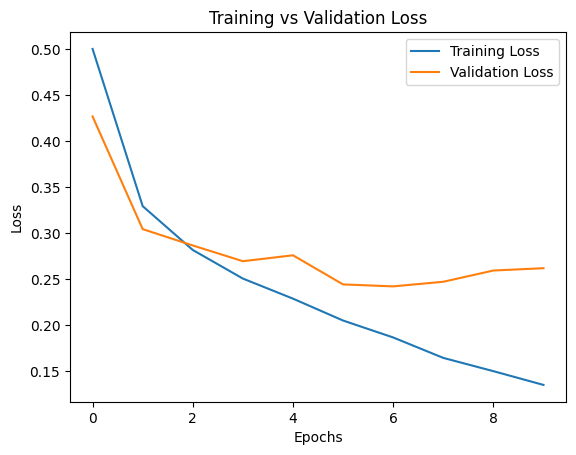

In [14]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9088 - loss: 0.2831
Test Loss: 0.2707260847091675
Test Accuracy: 0.9107999801635742


In [16]:
import numpy as np

predictions = model.predict(x_test[:5])

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:5], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step


In [17]:
class_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

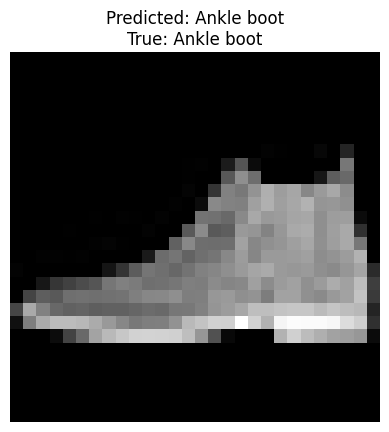

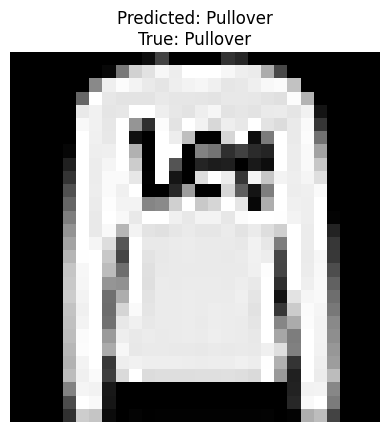

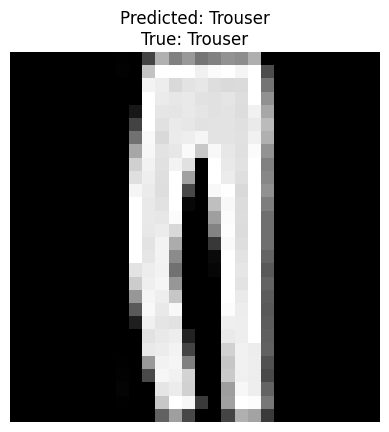

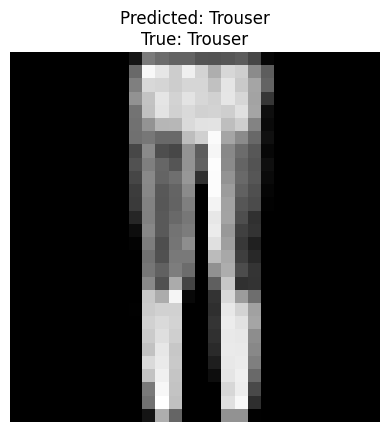

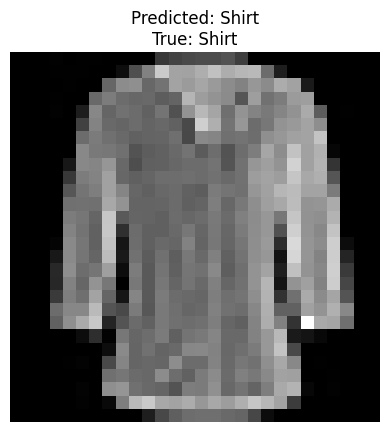

In [18]:
import matplotlib.pyplot as plt

for i in range(5):

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Predicted: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}"
    )

    plt.axis('off')
    plt.show()

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict classes
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[845   0  11  27   1   2 104   0  10   0]
 [  2 971   1  17   4   0   3   0   2   0]
 [ 21   0 856  10  42   0  68   0   3   0]
 [  8   0   7 930  24   0  24   0   7   0]
 [  2   0  47  26 855   0  63   0   7   0]
 [  0   0   0   0   0 987   0  10   1   2]
 [ 92   0  52  35  49   0 750   1  21   0]
 [  0   0   0   0   0  10   0 970   1  19]
 [  1   0   1   1   2   2   3   2 987   1]
 [  1   0   0   0   0   6   0  36   0 957]]


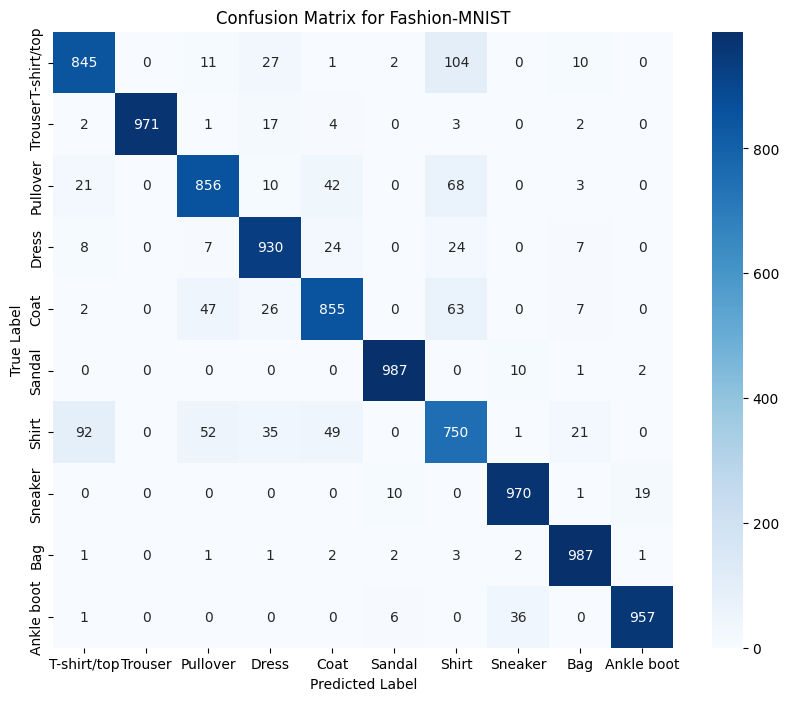

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fashion-MNIST")

plt.show()

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model2 = Sequential([

    # First Convolution Block
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    # Second Convolution Block
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    # Dropout layer
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Fully connected layer
    Dense(128,activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer
    Dense(10,activation='softmax')

])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,690 (1.92 MB)

 Trainable params: 503,690 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7174 - loss: 0.8048 - val_accuracy: 0.8773 - val_loss: 0.3414
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8653 - loss: 0.3811 - val_accuracy: 0.9003 - val_loss: 0.2768
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8864 - loss: 0.3149 - val_accuracy: 0.9099 - val_loss: 0.2523
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9013 - loss: 0.2782 - val_accuracy: 0.9143 - val_loss: 0.2414
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9098 - loss: 0.2509 - val_accuracy: 0.9185 - val_loss: 0.2250
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9124 - loss: 0.2353 - val_accuracy: 0.9189 - val_loss: 0.2213
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9158 - loss: 0.2260 - val_accuracy: 0.9189 - val_loss: 0.2275
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9245 - loss: 0.2051 - val_accuracy: 0

In [24]:
test_loss2, test_accuracy2 = model2.evaluate(x_test,y_test)

print("Improved Model Test Accuracy:",test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9184 - loss: 0.2483
Improved Model Test Accuracy: 0.9190999865531921


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9088 - loss: 0.2831
Test Loss: 0.2707260847091675
Test Accuracy: 0.9107999801635742
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


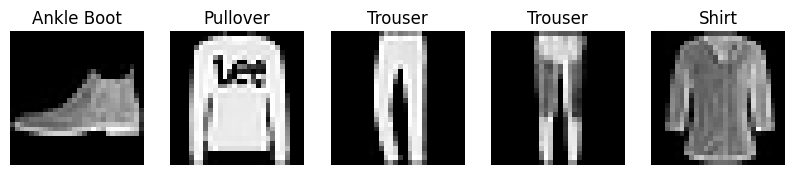

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Class labels
class_names = [
    "T-shirt/top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Ankle Boot"
]

# Predict
predictions = model.predict(x_test)

# Display 5 images
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    predicted_label = np.argmax(predictions[i])
    plt.title(class_names[predicted_label])
    plt.axis('off')

plt.show()

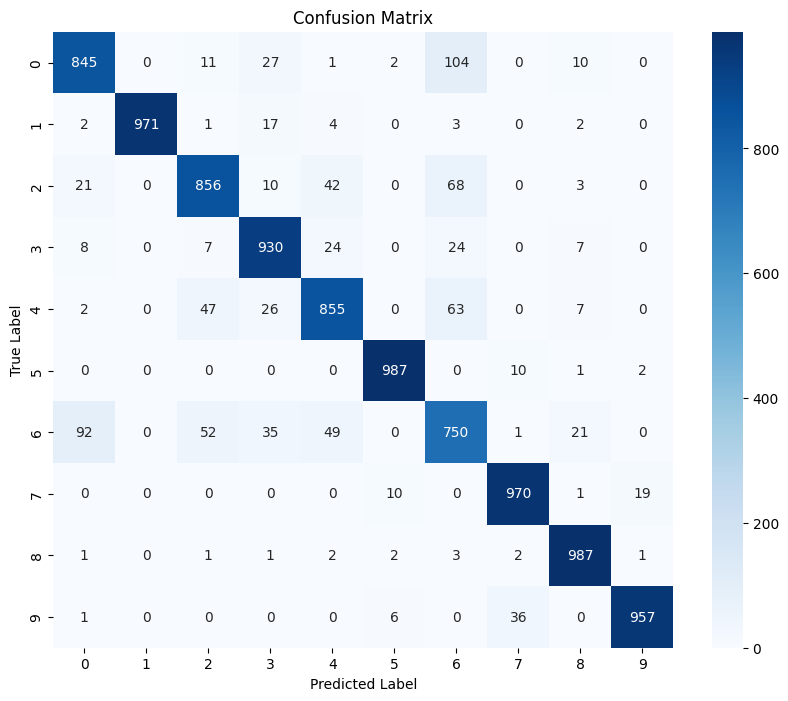

In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert predictions to class index
y_pred = np.argmax(predictions, axis=1)

# Convert y_test if one-hot encoded
if len(y_test.shape) > 1:
    y_test = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Input(shape=(28,28,1)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

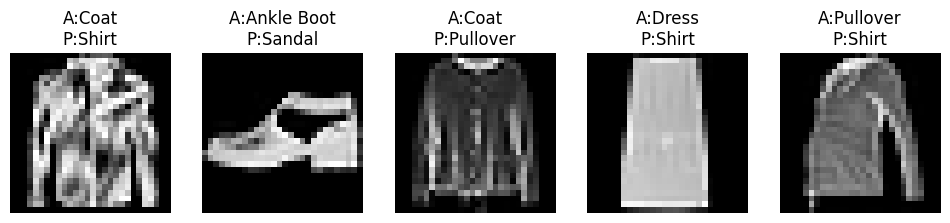

In [32]:
import numpy as np

wrong = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12,6))

for i in range(5):
    index = wrong[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')

    actual = class_names[y_test[index]]
    predicted = class_names[y_pred[index]]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


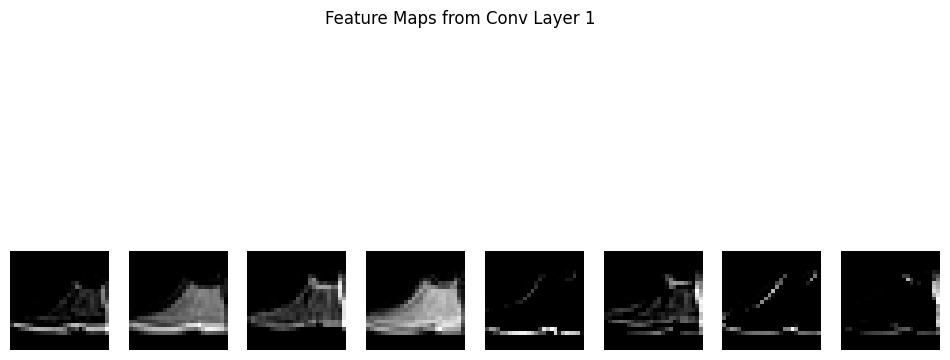

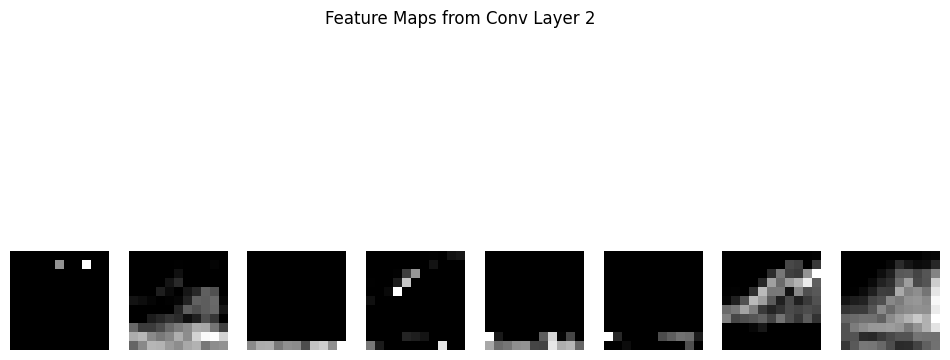

In [34]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# select one image
image = x_test[0].reshape(1,28,28,1)

# extract convolution layers
layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]

# create feature extraction model
feature_model = Model(inputs=model.inputs, outputs=layer_outputs)

# get feature maps
feature_maps = feature_model.predict(image)

# visualize feature maps
for layer_index, feature_map in enumerate(feature_maps):

    num_filters = feature_map.shape[-1]

    plt.figure(figsize=(12,6))

    for i in range(min(num_filters,8)):
        plt.subplot(1,8,i+1)
        plt.imshow(feature_map[0,:,:,i], cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Feature Maps from Conv Layer {layer_index+1}")
    plt.show()